<a href="https://colab.research.google.com/github/DanilLisenko/MovieSite/blob/main/%D0%9D%D0%B5%D0%B9%D1%80%D0%BE%D1%81%D0%B5%D1%82%D0%B8_%D1%82%D0%B5%D0%BA%D1%81%D1%82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install pymorphy2==0.8
!pip install pymorphy2-dicts-ru==2.4.417127.4579844

import pandas as pd
import numpy as np
import re
import nltk
import pymorphy2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from nltk.corpus import stopwords


DATASET_URL = "https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz"

print("Скачивание датасета...")
!wget -q $DATASET_URL -O lenta-ru-news.csv.gz
print("Датасет успешно скачан.")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 25.9 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=664f92c4602b2c9adac3436eefb95bc4a9830254ee301e7ea9fe5b4d39cbece7
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 91.1 MB/s eta 0:00:00
Скачивание датасета...
Датасет успешно скачан.


In [4]:
# Загрузка данных
print("Чтение CSV файла...")
df = pd.read_csv('lenta-ru-news.csv.gz', compression='gzip')

# Оставляем только нужные нам рубрики (топ-10 популярных)
target_topics = ['Россия', 'Мир', 'Экономика', 'Спорт', 'Культура',
                 'Наука и техника', 'Интернет и СМИ', 'Силовые структуры',
                 'Путешествия', 'Ценности']

df_filtered = df[df['topic'].isin(target_topics)].copy()

# Семплирование: берем по 3000 случайных статей из каждой рубрики
# Это решает проблему дисбаланса классов
SAMPLES_PER_CLASS = 3000
df_sampled = df_filtered.groupby('topic').apply(lambda x: x.sample(SAMPLES_PER_CLASS, random_state=42)).reset_index(drop=True)

print(f"Итоговый размер выборки: {len(df_sampled)} записей")
print("Распределение по классам:")
print(df_sampled['topic'].value_counts())

Чтение CSV файла...
Итоговый размер выборки: 30000 записей
Распределение по классам:
topic
Интернет и СМИ       3000
Культура             3000
Мир                  3000
Наука и техника      3000
Путешествия          3000
Россия               3000
Силовые структуры    3000
Спорт                3000
Ценности             3000
Экономика            3000
Name: count, dtype: int64


/tmp/ipython-input-634407872.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df_filtered.groupby('topic').apply(lambda x: x.sample(SAMPLES_PER_CLASS, random_state=42)).reset_index(drop=True)


In [5]:
# Загрузка стоп-слов (предлоги, союзы и т.д.)
nltk.download('stopwords')
stop_words = set(stopwords.words('russian'))
morph = pymorphy2.MorphAnalyzer()

def preprocess_text(text):
    if not isinstance(text, str): return ""
    # Оставляем только кириллицу и пробелы, приводим к нижнему регистру
    text = re.sub(r'[^а-яА-ЯёЁ\s]', '', text.lower())

    tokens = []
    # Разбиваем на слова
    for token in text.split():
        # Убираем стоп-слова и слишком короткие слова
        if token not in stop_words and len(token) > 2:
            # Лемматизация
            parsed_word = morph.parse(token)
            if parsed_word: # Проверяем, что список не пустой
                tokens.append(parsed_word[0].normal_form)

    return " ".join(tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [6]:
print("Начинаем обработку текстов")
tqdm.pandas() # Включаем прогресс-бар
df_sampled['clean_text'] = df_sampled['text'].progress_apply(preprocess_text)

# Проверка результата
print("\nПример исходного текста:", df_sampled['text'].iloc[:100])
print("Пример обработанного текста:", df_sampled['clean_text'].iloc[:100])

Начинаем обработку текстов (это займет 2-3 минуты)...


100%|██████████| 30000/30000 [06:22<00:00, 78.40it/s]


Пример исходного текста: 0     7 января на традиционной выставке Macworld Exp...
1     Организация по безопасности и сотрудничеству в...
2     Сервис микроблогов  Twitter назвал самое попул...
3     Национальная футбольная лига (NFL) согласилась...
4     Комиссия по регулированию телекоммуникаций Гру...
                            ...                        
95    Портал «Рамблер» запустил новую медиа-вертикал...
96    Компания Microsoft 23 мая представила на прохо...
97    В четверг, 27 апреля, в Москве стартует Всерос...
98    Количество заблокированных IP-адресов в связи ...
99    Facebook начал тестировать функцию перевода де...
Name: text, Length: 100, dtype: object
Пример обработанного текста: 0     январь традиционный выставка компания представ...
1     организация безопасность сотрудничество европа...
2     сервис микроблог назвать самый популярный сооб...
3     национальный футбольный лига согласиться вперв...
4     комиссия регулирование телекоммуникация грузия...
          

In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Гиперпараметры данных
MAX_NB_WORDS = 20000    # Размер словаря (топ-20000 слов)
MAX_SEQUENCE_LENGTH = 200 # Длина новости для нейросети

# Обучаем токенизатор
tokenizer = Tokenizer(num_words=MAX_NB_WORDS, oov_token='<UNK>')
tokenizer.fit_on_texts(df_sampled['clean_text'].values)

# Преобразуем текст в последовательности чисел
X = tokenizer.texts_to_sequences(df_sampled['clean_text'].values)
X = pad_sequences(X, maxlen=MAX_SEQUENCE_LENGTH)

# Кодируем ответы (рубрики)
y = pd.get_dummies(df_sampled['topic']).values
labels_map = pd.get_dummies(df_sampled['topic']).columns.tolist()

# Разделяем на Обучение (80%), Валидацию (10%) и Тест (10%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42, stratify=y_test)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (24000, 200)
Validation shape: (3000, 200)
Test shape: (3000, 200)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, SpatialDropout1D, Bidirectional, Dropout
from tensorflow.keras.optimizers import Adam, SGD

EMBEDDING_DIM = 128

def create_model(optimizer_name='adam', lstm_units=64, dropout_rate=0.2):
    model = Sequential()
    # Слой эмбеддингов: превращает индексы слов в векторы
    model.add(Embedding(MAX_NB_WORDS, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH))
    model.add(SpatialDropout1D(0.2)) # Отключаем целые векторы слов для регуляризации

    # Основной слой: Двунаправленная LSTM
    model.add(Bidirectional(LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.0)))

    # Полносвязная часть
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(len(labels_map), activation='softmax')) # Выходной слой = число рубрик

    # Компиляция
    if optimizer_name == 'sgd':
        opt = SGD(learning_rate=0.01, momentum=0.9)
    else:
        opt = Adam(learning_rate=0.001)

    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

In [9]:
#ЗАПУСК ЭКСПЕРИМЕНТОВ

experiments = [
    {'name': 'Exp 1: Base (Adam, 64 LSTM)', 'opt': 'adam', 'lstm': 64, 'drop': 0.2, 'batch': 32},
    {'name': 'Exp 2: Large (Adam, 128 LSTM)', 'opt': 'adam', 'lstm': 128, 'drop': 0.3, 'batch': 64},
    {'name': 'Exp 3: SGD Optimizer', 'opt': 'sgd', 'lstm': 64, 'drop': 0.2, 'batch': 32},
    {'name': 'Exp 4: High Dropout (0.4)', 'opt': 'adam', 'lstm': 64, 'drop': 0.4, 'batch': 32},
    {'name': 'Exp 5: Big Batch (128)', 'opt': 'adam', 'lstm': 64, 'drop': 0.2, 'batch': 128}
]

results = []
all_histories = {}
best_model = None
best_acc = 0
best_exp_name = ""

EPOCHS = 5

for exp in experiments:
    print(f"\n--- Запуск: {exp['name']} ---")

    # Создаем модель
    model = create_model(exp['opt'], exp['lstm'], exp['drop'])

    # Обучаем и СОХРАНЯЕМ историю в переменную history
    history = model.fit(X_train, y_train,
                        epochs=EPOCHS,
                        batch_size=exp['batch'],
                        validation_data=(X_val, y_val),
                        verbose=1)

    # Сохраняем историю этого эксперимента в общий словарь
    all_histories[exp['name']] = history.history

    # Проверка на тесте
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Точность на тесте: {acc*100:.2f}%")

    # Сохраняем итоговый результат
    results.append({
        'Модель': exp['name'],
        'Точность (%)': round(acc * 100, 2)
    })

    # Если модель лучшая — запоминаем её и её имя
    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_exp_name = exp['name']

print(f"\nЛучшая модель: {best_exp_name} с точностью {best_acc*100:.2f}%")


--- Запуск: Exp 1: Base (Adam, 64 LSTM) ---
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.3424 - loss: 1.7426 - val_accuracy: 0.7077 - val_loss: 0.8918
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.7383 - loss: 0.8161 - val_accuracy: 0.7497 - val_loss: 0.7639
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8175 - loss: 0.5730 - val_accuracy: 0.7587 - val_loss: 0.7721
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8559 - loss: 0.4705 - val_accuracy: 0.7683 - val_loss: 0.7769
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8932 - loss: 0.3672 - val_accuracy: 0.7600 - val_loss: 0.8015
Точность на тесте: 74.47%

--- Запуск: Exp 2: Large (Adam, 128 LSTM) ---
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.2855 - loss: 1.8628 - val_accuracy: 0.6533 - val_loss: 1.0437
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.7109 - loss: 0.8818 - val_accuracy: 0.7603 - val_loss: 0.7470
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━

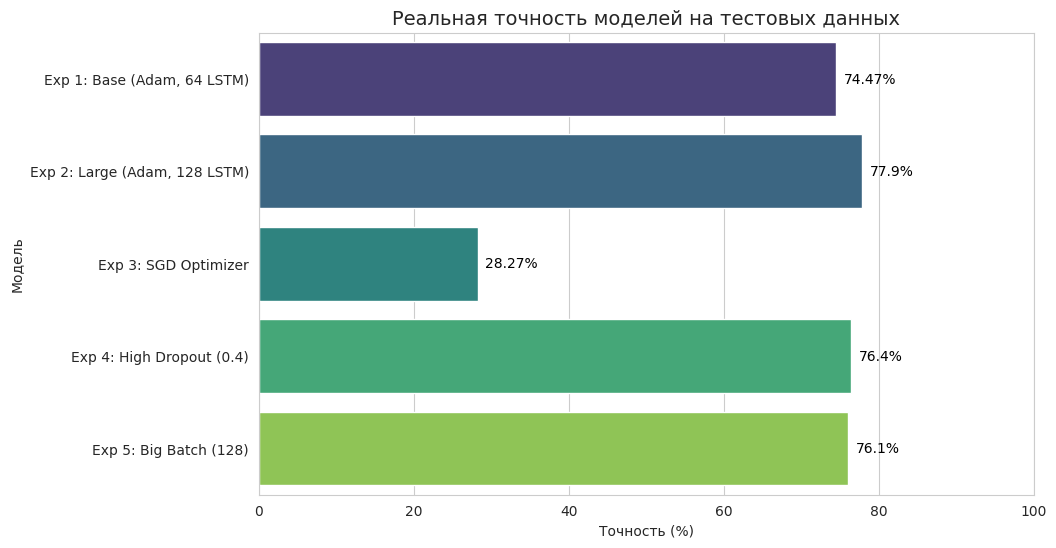

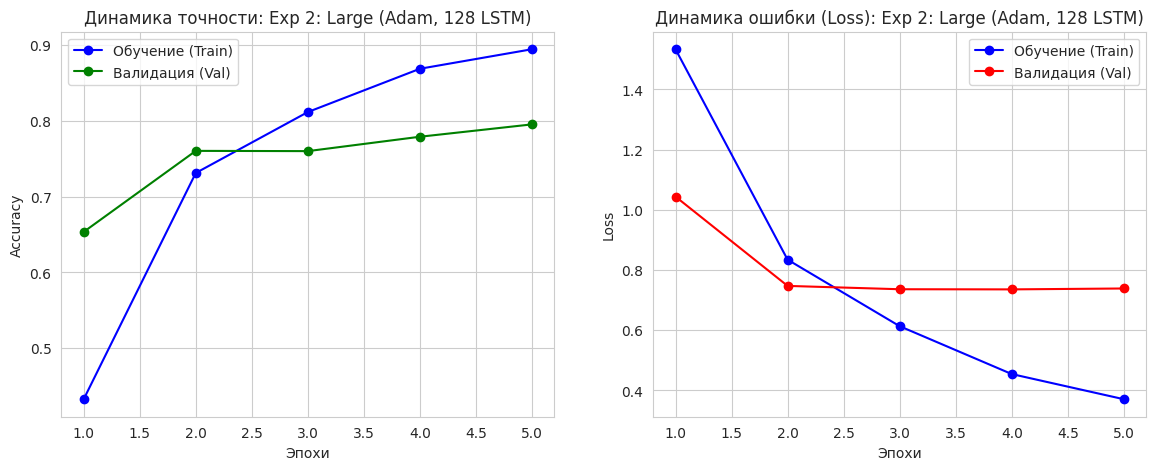

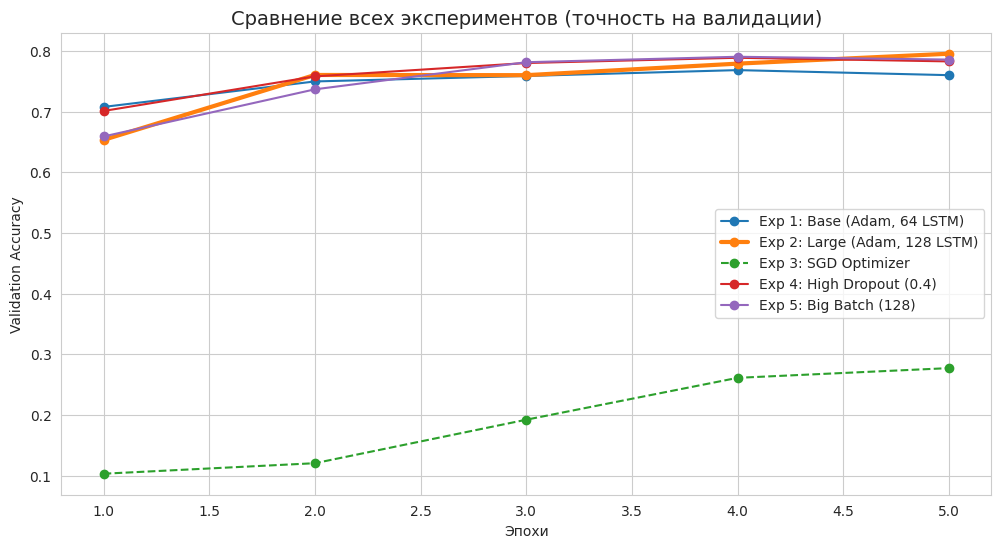

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 10)

# ==========================================
# ГРАФИК 1: Итоговое сравнение
# ==========================================
plt.figure(figsize=(10, 6))

df_res = pd.DataFrame(results)

colors = sns.color_palette("viridis", len(df_res))

barplot = sns.barplot(x='Точность (%)', y='Модель', data=df_res, hue='Модель', palette=colors, legend=False)

plt.title('Реальная точность моделей на тестовых данных', fontsize=14)
plt.xlim(0, 100)

for index, row in df_res.iterrows():
    barplot.text(row['Точность (%)'] + 1, index, f"{row['Точность (%)']}%", color='black', ha="left", va="center")

plt.show()

# ==========================================
# ГРАФИК 2: Кривые обучения ЛУЧШЕЙ модели
# ==========================================

best_history = all_histories[best_exp_name]
real_epochs = range(1, len(best_history['accuracy']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График точности
ax1.plot(real_epochs, best_history['accuracy'], 'b-o', label='Обучение (Train)')
ax1.plot(real_epochs, best_history['val_accuracy'], 'g-o', label='Валидация (Val)')
ax1.set_title(f'Динамика точности: {best_exp_name}', fontsize=12)
ax1.set_xlabel('Эпохи')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# График ошибки (Loss)
ax2.plot(real_epochs, best_history['loss'], 'b-o', label='Обучение (Train)')
ax2.plot(real_epochs, best_history['val_loss'], 'r-o', label='Валидация (Val)')
ax2.set_title(f'Динамика ошибки (Loss): {best_exp_name}', fontsize=12)
ax2.set_xlabel('Эпохи')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.show()

# ==========================================
# ГРАФИК 3: Сравнение скорости обучения всех моделей
# ==========================================
plt.figure(figsize=(12, 6))

for name, history_data in all_histories.items():
    linewidth = 3 if name == best_exp_name else 1.5
    linestyle = '--' if 'SGD' in name else '-'

    plt.plot(range(1, EPOCHS + 1), history_data['val_accuracy'],
             label=name, linewidth=linewidth, linestyle=linestyle, marker='o')

plt.title('Сравнение всех экспериментов (точность на валидации)', fontsize=14)
plt.xlabel('Эпохи')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
from google.colab import drive
drive.mount('/content/drive')

import os
save_path = '/content/drive/My Drive/MyNewsModel'
if not os.path.exists(save_path):
    os.makedirs(save_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import pickle

# 1. Сохраняем модель Keras
model_file = os.path.join(save_path, 'best_model.keras')
best_model.save(model_file)
print(f"Модель сохранена в: {model_file}")

# 2. Сохраняем токенизатор (словарь слов)
tokenizer_file = os.path.join(save_path, 'tokenizer.pickle')
with open(tokenizer_file, 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Токенизатор сохранен в: {tokenizer_file}")

# 3. Сохраняем список категорий (чтобы знать, что значит класс 0, 1, 2...)
labels_file = os.path.join(save_path, 'labels.pickle')
with open(labels_file, 'wb') as handle:
    pickle.dump(labels_map, handle, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Метки классов сохранены в: {labels_file}")

Модель сохранена в: /content/drive/My Drive/MyNewsModel/best_model.keras
Токенизатор сохранен в: /content/drive/My Drive/MyNewsModel/tokenizer.pickle
Метки классов сохранены в: /content/drive/My Drive/MyNewsModel/labels.pickle


In [17]:
import os
import pickle
import numpy as np
import pandas as pd
import re
import nltk
import time
import pymorphy2
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from google.colab import drive
from IPython.display import clear_output

# 1. Настройки
MAX_SEQUENCE_LENGTH = 200
load_path = '/content/drive/My Drive/MyNewsModel'

# 2. Подготовка
drive.mount('/content/drive')
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('russian'))
morph = pymorphy2.MorphAnalyzer()

# 3. Загрузка
try:
    model = load_model(os.path.join(load_path, 'best_model.keras'))
    with open(os.path.join(load_path, 'tokenizer.pickle'), 'rb') as handle:
        tokenizer = pickle.load(handle)
    with open(os.path.join(load_path, 'labels.pickle'), 'rb') as handle:
        labels_map = pickle.load(handle)
    print("Модель успешно загружена!")
except Exception as e:
    print(f"Ошибка загрузки: {e}")

# 4. Функция очистки текста
def preprocess_text_inference(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'[^а-яА-ЯёЁ\s]', '', text.lower())
    tokens = []
    for token in text.split():
        if token not in stop_words and len(token) > 2:
            parsed = morph.parse(token)
            if parsed:
                tokens.append(parsed[0].normal_form)
    return " ".join(tokens)

# 5. Интерактивный режим
def interactive_prediction():
    sns.set_style("whitegrid")

    print("\n" + "="*40)
    print(" МОДЕЛЬ ГОТОВА К РАБОТЕ ")
    print(" Введите текст новости (или 'exit' для выхода)")
    print("="*40)


    time.sleep(0.5)

    while True:
        try:
            user_text = input("\nВведите текст новости: ")
        except EOFError:
            break

        if user_text.lower() in ['exit', 'выход', 'quit']:
            print("Работа завершена.")
            break

        if len(user_text) < 5:
            print("Слишком короткий текст.")
            continue

        # Очищаем экран
        clear_output(wait=True)
        print(f"📝 ВАШ ТЕКСТ: {user_text}\n")

        # Обработка
        clean_text = preprocess_text_inference(user_text)
        seq = tokenizer.texts_to_sequences([clean_text])
        padded = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH)

        # Предсказание
        pred_probs = model.predict(padded, verbose=0)[0]

        # Подготовка данных для графика
        df_probs = pd.DataFrame({
            'Рубрика': labels_map,
            'Вероятность': pred_probs
        })
        df_probs = df_probs.sort_values(by='Вероятность', ascending=False)

        top_category = df_probs.iloc[0]['Рубрика']
        top_confidence = df_probs.iloc[0]['Вероятность']

        print(f">>> Основной прогноз: {top_category.upper()}")
        print(f"    Уверенность: {top_confidence*100:.1f}%")

        # Рисуем график
        plt.figure(figsize=(10, 5))
        barplot = sns.barplot(
            x='Вероятность',
            y='Рубрика',
            data=df_probs,
            hue='Рубрика',
            palette='viridis',
            legend=False
        )

        plt.title('Распределение вероятностей', fontsize=14)
        plt.xlim(0, 1.15)

        for index, (value, name) in enumerate(zip(df_probs['Вероятность'], df_probs['Рубрика'])):
            fw = 'bold' if index == 0 else 'normal'
            plt.text(value + 0.01, index, f"{value*100:.1f}%", va='center', color='black', fontsize=10, fontweight=fw)

        plt.show()
        plt.close()
        time.sleep(1)

# Запуск
interactive_prediction()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Модель успешно загружена!

 МОДЕЛЬ ГОТОВА К РАБОТЕ 
 Введите текст новости (или 'exit' для выхода)

Введите текст новости: выход
Работа завершена.
